# Supermarket Transaction Analysis for Decision Support: Product-Line Priorities and Branch-Level Differences

## 1. Project Introduction

This notebook presents a reusable Python workflow for supermarket transaction analysis. The current version uses one supermarket Excel file as a demonstration dataset, but the same workflow can be applied to other structured retail transaction inputs such as POS exports, CSV sales reports, ERP extracts, or database outputs.

The purpose of the project is to help supermarket and branch managers identify which product lines deserve higher priority and whether branches show differences that justify more localised strategies. To do this, the notebook compares product-line sales, gross income, concentration patterns, and branch-level performance.

## 2. Data Loading

The analysis starts by reading the supermarket transaction data into a pandas DataFrame. The file used here is treated as an example input for the wider workflow developed in this notebook.

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')

primary_color = '#2F6B5B'
secondary_color = '#6AA38E'
accent_color = '#D98B5F'
branch_colors = ['#2F6B5B', '#6AA38E', '#D9B26F']

In [198]:
# Reusable data-loading function
def load_data(file_path):
    if file_path.endswith('.xlsx'):
        return pd.read_excel(file_path)
    elif file_path.endswith('.csv'):
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format. Please use .xlsx or .csv.")

In [199]:
# Demonstration: current dataset input
df = load_data("supermarket.xlsx")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08:00,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29:00,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23:00,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33:00,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37:00,Ewallet,604.17,4.76,30.21,5.30


## 3. Dataset Overview

The dataset contains 1,000 transaction records and 17 variables. Key fields include `Product line`, `Branch`, `Total`, `gross income`, and `Date`, all of which are useful for answering the business question.

It works well as a demonstration dataset because it supports product comparisons, branch comparisons, and basic time preparation. While the example here uses a single Excel workbook, the same structure could be adapted to similar supermarket transaction data from other sources.

## 4. Initial Inspection

Before moving into analysis, the dataset is checked for its shape, column names, data types, and missing values. This is a basic validation step to confirm that the file is usable and that the main variables are in the expected format.

In [200]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values:")
print(df.isna().sum())

Shape of the dataset:
(1000, 17)

Column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64    

## 5. Data Cleaning and Preparation

Only light preparation is needed here. The aim is simply to make the transaction data ready for product-line, concentration, and branch-level analysis rather than to carry out heavy data cleaning.

In [201]:
# Confirm date format
df['Date'] = pd.to_datetime(df['Date'])

# Create simple time-based variables
df['month'] = df['Date'].dt.month
df['day_name'] = df['Date'].dt.day_name()

# Check key numeric columns
numeric_columns = ['Total', 'gross income', 'Quantity', 'Rating']
df[numeric_columns].describe()

,Total,gross income,Quantity,Rating
count,"1,000.00","1,000.00","1,000.00","1,000.00"
mean,322.97,15.38,5.51,6.97
std,245.89,11.71,2.92,1.72
min,10.68,0.51,1.00,4.00
25%,124.42,5.92,3.00,5.50
50%,253.85,12.09,5.00,7.00
75%,471.35,22.45,8.00,8.50
max,"1,042.65",49.65,10.00,10.00


In [202]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
month                      0
day_name                   0
dtype: int64

In [203]:
df['Date'].min(), df['Date'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2019-03-30 00:00:00'))

### Cleaning Summary

Overall, the dataset needed very little cleaning. The `Date` field was converted and used to create `month` and `day_name`, key numeric variables were checked, and no missing values were found in the main fields. This means the data are already in a workable state for the analysis that follows.

## 6. Product-Line Priority Analysis

This section compares product lines using both total sales and gross income. Looking at the two measures together gives a better sense of which lines matter most commercially, rather than relying on sales alone.

In [204]:
product_sales = (
    df.groupby('Product line', as_index=False)['Total']
      .sum()
      .sort_values(by='Total', ascending=False)
)

product_sales

,Product line,Total
2,Food and beverages,"56,144.84"
5,Sports and travel,"55,122.83"
0,Electronic accessories,"54,337.53"
1,Fashion accessories,"54,305.89"
4,Home and lifestyle,"53,861.91"
3,Health and beauty,"49,193.74"


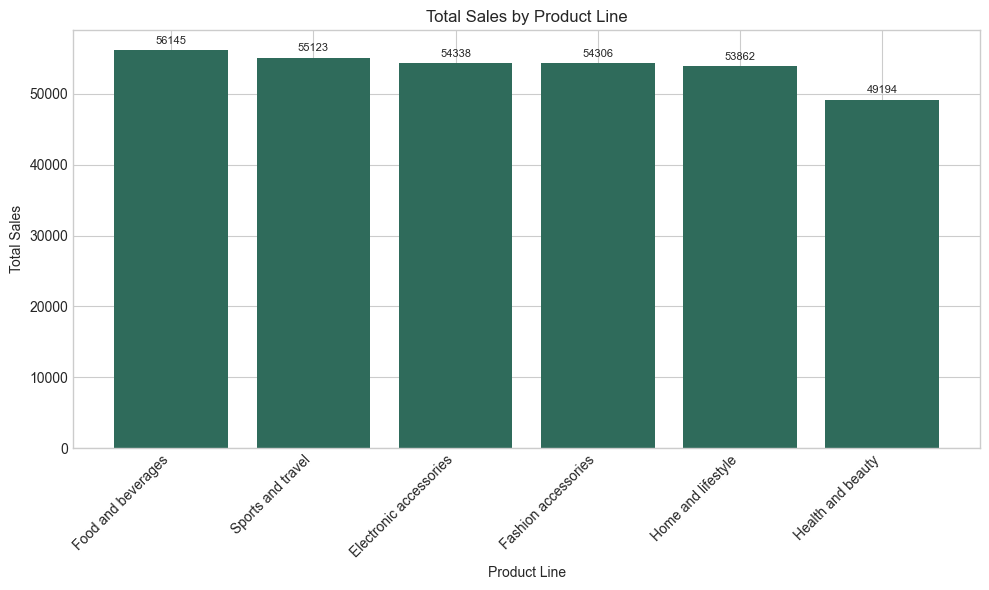

In [205]:

# Bar chart: total sales by product line
plt.figure(figsize=(10, 6))
bars = plt.bar(product_sales['Product line'], product_sales['Total'], color=primary_color)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product Line')
plt.gca().bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [206]:
product_income = (
    df.groupby('Product line', as_index=False)['gross income']
      .sum()
      .sort_values(by='gross income', ascending=False)
)

product_income

,Product line,gross income
2,Food and beverages,"2,673.56"
5,Sports and travel,"2,624.90"
0,Electronic accessories,"2,587.50"
1,Fashion accessories,"2,585.99"
4,Home and lifestyle,"2,564.85"
3,Health and beauty,"2,342.56"


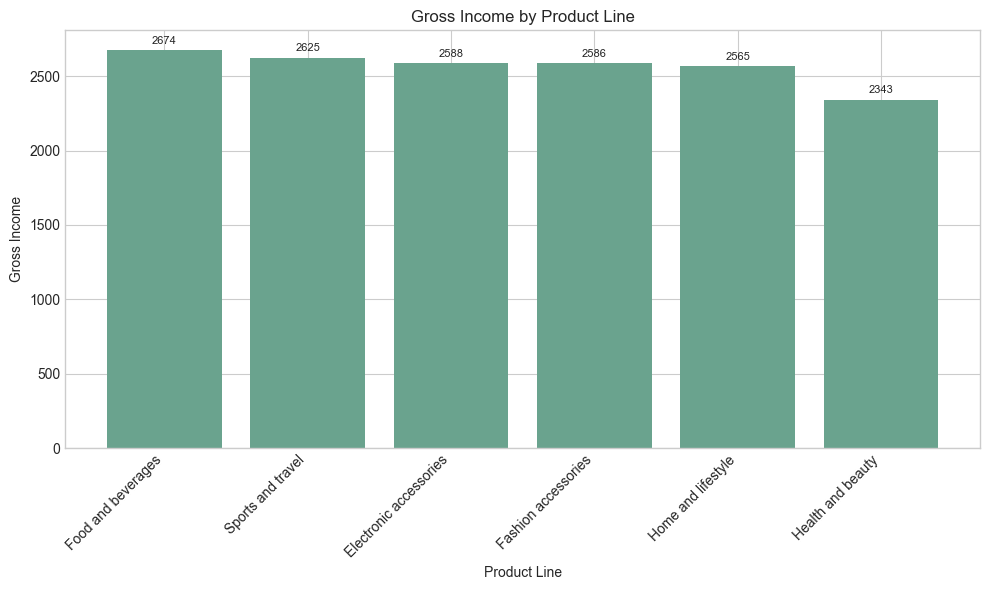

In [207]:
# Bar chart: gross income by product line
plt.figure(figsize=(10, 6))
bars = plt.bar(
    product_income['Product line'],
    product_income['gross income'],
    color=secondary_color,
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Line')
plt.ylabel('Gross Income')
plt.title('Gross Income by Product Line')
plt.gca().bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [208]:
product_summary = product_sales.merge(product_income, on='Product line')
product_summary = product_summary.sort_values(by='Total', ascending=False)
product_summary['Sales Share'] = product_summary['Total'] / product_summary['Total'].sum()
product_summary['Income Share'] = (
    product_summary['gross income'] / product_summary['gross income'].sum()
)

product_summary

,Product line,Total,gross income,Sales Share,Income Share
0,Food and beverages,"56,144.84","2,673.56",0.17,0.17
1,Sports and travel,"55,122.83","2,624.90",0.17,0.17
2,Electronic accessories,"54,337.53","2,587.50",0.17,0.17
3,Fashion accessories,"54,305.89","2,585.99",0.17,0.17
4,Home and lifestyle,"53,861.91","2,564.85",0.17,0.17
5,Health and beauty,"49,193.74","2,342.56",0.15,0.15


### Interpretation of Product-Line Priorities

Sales and gross income are clearly not spread evenly across product lines. `Food and beverages` ranks first on both measures, making it the strongest line in this dataset. `Sports and travel` and `Electronic accessories` also perform well, so a relatively small group of product lines contributes a large share of supermarket performance.

The similarity between the sales and gross-income rankings also matters. It suggests that the same categories perform strongly across more than one indicator, which makes them more convincing priorities for stock planning and promotion.

## 7. Sales and Income Concentration Analysis

Simple ranking shows which product lines come first, but it does not show how concentrated performance is. This section looks at how much of total sales and gross income comes from the top product lines, which helps show whether the supermarket depends heavily on a small set of categories.

In [209]:
top3_sales_share = product_sales.head(3)['Total'].sum() / product_sales['Total'].sum()
top5_sales_share = product_sales.head(5)['Total'].sum() / product_sales['Total'].sum()

top3_income_share = product_income.head(3)['gross income'].sum() / product_income['gross income'].sum()
top5_income_share = product_income.head(5)['gross income'].sum() / product_income['gross income'].sum()

concentration_summary = pd.DataFrame({
    'Metric': [
        'Top 3 Share of Total Sales',
        'Top 5 Share of Total Sales',
        'Top 3 Share of Gross Income',
        'Top 5 Share of Gross Income'
    ],
    'Share': [
        top3_sales_share,
        top5_sales_share,
        top3_income_share,
        top5_income_share
    ]
})

concentration_summary

,Metric,Share
0,Top 3 Share of Total Sales,0.51
1,Top 5 Share of Total Sales,0.85
2,Top 3 Share of Gross Income,0.51
3,Top 5 Share of Gross Income,0.85


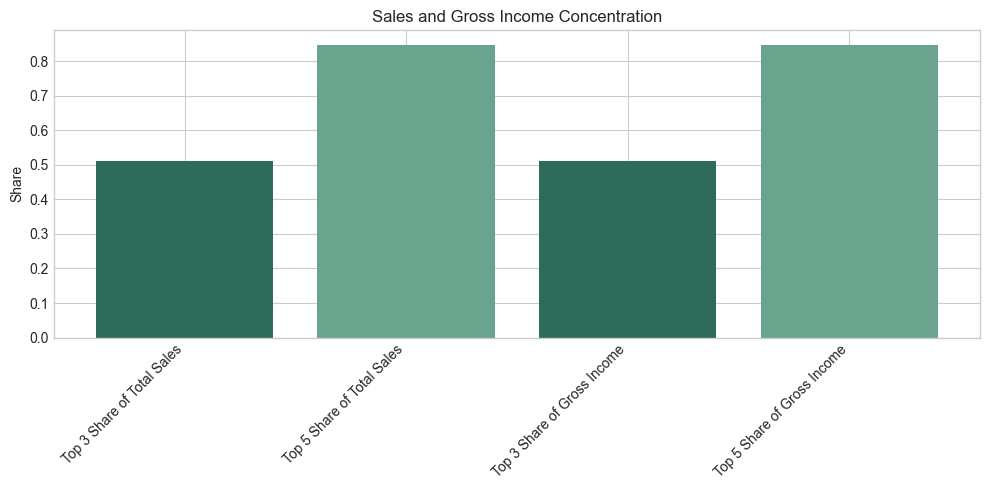

In [210]:
# Visualise concentration shares
plt.figure(figsize=(10, 5))
plt.bar(
    concentration_summary['Metric'],
    concentration_summary['Share'],
    color=[primary_color, secondary_color, primary_color, secondary_color]
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Share')
plt.title('Sales and Gross Income Concentration')
plt.tight_layout()
plt.show()

In [211]:
# Contribution table for top product lines by sales and income
sales_contribution = product_sales.copy()
sales_contribution['Sales Share'] = sales_contribution['Total'] / sales_contribution['Total'].sum()

income_contribution = product_income.copy()
income_contribution['Income Share'] = income_contribution['gross income'] / income_contribution['gross income'].sum()

sales_contribution.head(5), income_contribution.head(5)

(             Product line     Total  Sales Share
 2      Food and beverages 56,144.84         0.17
 5       Sports and travel 55,122.83         0.17
 0  Electronic accessories 54,337.53         0.17
 1     Fashion accessories 54,305.89         0.17
 4      Home and lifestyle 53,861.91         0.17,
              Product line  gross income  Income Share
 2      Food and beverages      2,673.56          0.17
 5       Sports and travel      2,624.90          0.17
 0  Electronic accessories      2,587.50          0.17
 1     Fashion accessories      2,585.99          0.17
 4      Home and lifestyle      2,564.85          0.17)

### Interpretation of Concentration

The concentration results add a clearer structural view of supermarket performance. The top three product lines generate just over half of both total sales and gross income, while the top five account for roughly 85% of both measures. This shows that the business is not driven by only one category, but performance is still concentrated in a relatively small set of product lines.

From a managerial point of view, this matters because strong categories deserve attention, but heavy dependence on a small part of the product mix can also create risk. That is why concentration analysis adds more depth than ranking alone.

## 8. Branch-Level Difference Analysis

Overall branch totals show whether one branch performs more strongly than another, but they do not explain where that performance comes from. This section compares branches at the overall level, the product-line level, and the within-branch concentration level.

In [212]:
# Overall branch performance
branch_summary = (
    df.groupby('Branch', as_index=False)[['Total', 'gross income', 'Quantity']]
      .sum()
      .sort_values(by='Total', ascending=False)
)
branch_summary['Sales Share (%)'] = branch_summary['Total'] / branch_summary['Total'].sum() * 100

branch_summary

,Branch,Total,gross income,Quantity,Sales Share (%)
2,C,"110,568.71","5,265.18",1831,34.24
0,A,"106,200.37","5,057.16",1859,32.88
1,B,"106,197.67","5,057.03",1820,32.88


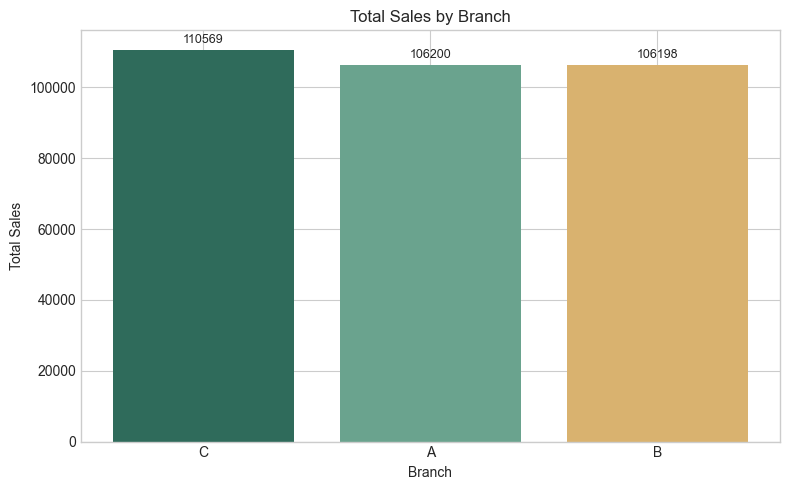

In [213]:
# Bar chart: total sales by branch
plt.figure(figsize=(8, 5))
bars = plt.bar(branch_summary['Branch'], branch_summary['Total'], color=branch_colors)
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.title('Total Sales by Branch')
plt.gca().bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [214]:
# Product-line sales by branch
branch_product_sales = (
    df.groupby(['Branch', 'Product line'], as_index=False)['Total']
      .sum()
)

branch_product_sales.head()

,Branch,Product line,Total
0,A,Electronic accessories,"18,317.11"
1,A,Fashion accessories,"16,332.51"
2,A,Food and beverages,"17,163.10"
3,A,Health and beauty,"12,597.75"
4,A,Home and lifestyle,"22,417.20"


To make branch patterns easier to read, the next table reshapes product-line sales by branch. This makes it easier to see whether the same lines lead across all branches or whether each branch has its own stronger categories.

In [215]:
# Pivot table: product-line sales by branch
branch_product_pivot = df.pivot_table(
    values='Total',
    index='Product line',
    columns='Branch',
    aggfunc='sum'
)

branch_product_pivot

Branch,A,B,C
Product line,,,
Electronic accessories,"18,317.11","17,051.44","18,968.97"
Fashion accessories,"16,332.51","16,413.32","21,560.07"
Food and beverages,"17,163.10","15,214.89","23,766.85"
Health and beauty,"12,597.75","19,980.66","16,615.33"
Home and lifestyle,"22,417.20","17,549.16","13,895.55"
Sports and travel,"19,372.70","19,988.20","15,761.93"


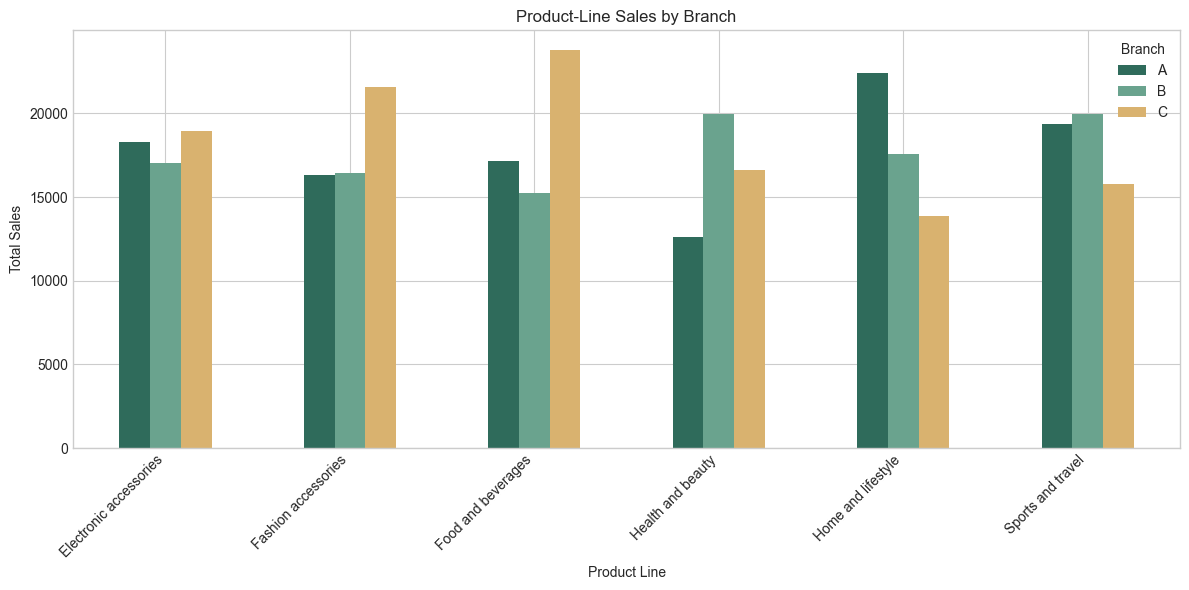

In [216]:
# Grouped bar chart: product-line sales by branch
branch_product_pivot.plot(kind='bar', figsize=(12, 6), color=branch_colors)
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.title('Product-Line Sales by Branch')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Branch')
plt.tight_layout()
plt.show()

In [217]:
branch_top3_sales = (
    df.groupby(['Branch', 'Product line'], as_index=False)['Total']
      .sum()
      .sort_values(['Branch', 'Total'], ascending=[True, False])
      .groupby('Branch')
      .head(3)
)

branch_top3_sales

,Branch,Product line,Total
4,A,Home and lifestyle,"22,417.20"
5,A,Sports and travel,"19,372.70"
0,A,Electronic accessories,"18,317.11"
11,B,Sports and travel,"19,988.20"
9,B,Health and beauty,"19,980.66"
10,B,Home and lifestyle,"17,549.16"
14,C,Food and beverages,"23,766.85"
13,C,Fashion accessories,"21,560.07"
12,C,Electronic accessories,"18,968.97"


In [218]:
branch_top3_income = (
    df.groupby(['Branch', 'Product line'], as_index=False)['gross income']
      .sum()
      .sort_values(['Branch', 'gross income'], ascending=[True, False])
      .groupby('Branch')
      .head(3)
)

branch_top3_income

,Branch,Product line,gross income
4,A,Home and lifestyle,"1,067.49"
5,A,Sports and travel,922.51
0,A,Electronic accessories,872.24
11,B,Sports and travel,951.82
9,B,Health and beauty,951.46
10,B,Home and lifestyle,835.67
14,C,Food and beverages,"1,131.75"
13,C,Fashion accessories,"1,026.67"
12,C,Electronic accessories,903.28


In [219]:
branch_concentration = (
    df.groupby(['Branch', 'Product line'], as_index=False)['Total']
      .sum()
      .sort_values(['Branch', 'Total'], ascending=[True, False])
)

branch_totals = (
    branch_concentration.groupby('Branch', as_index=False)['Total']
    .sum()
    .rename(columns={'Total': 'Branch Total'})
)

branch_top3_totals = (
    branch_concentration.groupby('Branch')
    .head(3)
    .groupby('Branch', as_index=False)['Total']
    .sum()
    .rename(columns={'Total': 'Top 3 Total'})
)

branch_top3_share = branch_top3_totals.merge(branch_totals, on='Branch')
branch_top3_share['Top 3 Sales Share'] = (
    branch_top3_share['Top 3 Total'] / branch_top3_share['Branch Total']
)
branch_top3_share = branch_top3_share[['Branch', 'Top 3 Sales Share']]

branch_top3_share

,Branch,Top 3 Sales Share
0,A,0.57
1,B,0.54
2,C,0.58


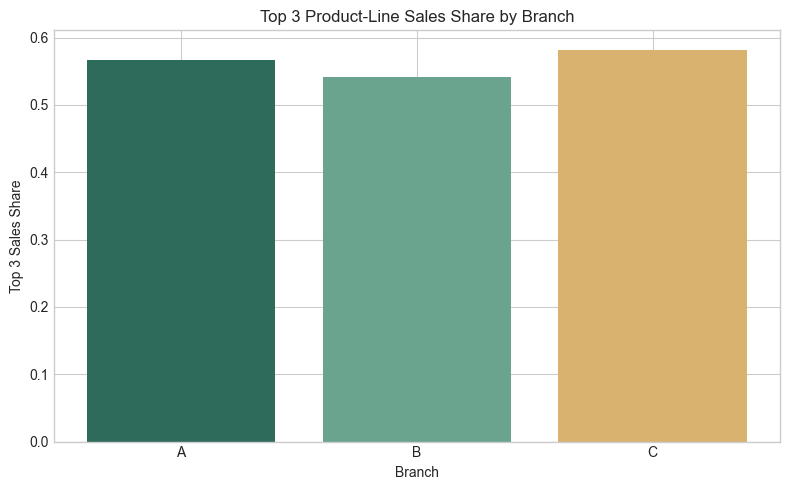

In [220]:
plt.figure(figsize=(8, 5))
plt.bar(branch_top3_share['Branch'], branch_top3_share['Top 3 Sales Share'], color=branch_colors)
plt.xlabel('Branch')
plt.ylabel('Top 3 Sales Share')
plt.title('Top 3 Product-Line Sales Share by Branch')
plt.tight_layout()
plt.show()

In [221]:
# Compare top product lines by branch using pivot
branch_top_pivot = branch_top3_sales.pivot_table(
    values='Total',
    index='Product line',
    columns='Branch',
    aggfunc='sum'
)

branch_top_pivot

Branch,A,B,C
Product line,,,
Electronic accessories,"18,317.11",NaN,"18,968.97"
Fashion accessories,NaN,NaN,"21,560.07"
Food and beverages,NaN,NaN,"23,766.85"
Health and beauty,NaN,"19,980.66",NaN
Home and lifestyle,"22,417.20","17,549.16",NaN
Sports and travel,"19,372.70","19,988.20",NaN


### Branch-Specific Product Priorities

The branch-level results show that branch strategy should not be based on total sales alone. Branch A is led by `Home and lifestyle`, Branch B by `Sports and travel`, and Branch C by `Food and beverages`, which means the strongest categories are not identical across locations.

The concentration results add another layer to this picture. In each branch, the top three product lines account for roughly 54% to 58% of total branch sales. This means each branch depends meaningfully on a relatively small group of categories, but the exact mix differs by branch. For managers, this supports a combined strategy: keep a few company-wide priorities, but allow branch-level adjustment in stocking and promotion.

## 9. Reusable Workflow Functions

The loading function was introduced earlier in the notebook. The helper functions below make the workflow easier to reuse by reducing hard-coded groupby steps and by making category, branch, and concentration analysis easier to repeat.

The functions below assume a structured transaction dataset with fields for product category, branch, sales value, and income value. This means the workflow is reusable across similar supermarket datasets, even when the input file changes, as long as the data structure remains comparable.

In [222]:
COLUMN_MAP = {
    'product_line': 'Product line',
    'branch': 'Branch',
    'sales': 'Total',
    'income': 'gross income',
    'date': 'Date'
}

In [223]:
# Reusable summary function by category
def summarise_by_category(dataframe, category_col, metric_col):
    summary = (
        dataframe.groupby(category_col, as_index=False)[metric_col]
        .sum()
        .sort_values(by=metric_col, ascending=False)
    )
    return summary

In [224]:
# Reusable summary function by branch and category
def summarise_branch_category(dataframe, branch_col, branch_name, category_col, metric_col):
    summary = (
        dataframe[dataframe[branch_col] == branch_name]
        .groupby(category_col, as_index=False)[metric_col]
        .sum()
        .sort_values(by=metric_col, ascending=False)
    )
    return summary

In [225]:
# Reusable concentration function
def calculate_top_n_share(summary_df, metric_col, n=3):
    total_value = summary_df[metric_col].sum()
    top_n_value = summary_df.head(n)[metric_col].sum()
    return top_n_value / total_value

In [226]:
# Quick demonstration
summarise_by_category(df, COLUMN_MAP['product_line'], COLUMN_MAP['sales']).head()

,Product line,Total
2,Food and beverages,"56,144.84"
5,Sports and travel,"55,122.83"
0,Electronic accessories,"54,337.53"
1,Fashion accessories,"54,305.89"
4,Home and lifestyle,"53,861.91"


In [227]:
summarise_branch_category(
    df,
    COLUMN_MAP['branch'],
    'A',
    COLUMN_MAP['product_line'],
    COLUMN_MAP['sales']
)

,Product line,Total
4,Home and lifestyle,"22,417.20"
5,Sports and travel,"19,372.70"
0,Electronic accessories,"18,317.11"
2,Food and beverages,"17,163.10"
1,Fashion accessories,"16,332.51"
3,Health and beauty,"12,597.75"


In [228]:
calculate_top_n_share(product_sales, COLUMN_MAP['sales'], n=3)

np.float64(0.512762389666312)

Together, these functions make the notebook easier to reuse with different input files, different categories, and different business metrics. They also make the analysis less dependent on one fixed spreadsheet structure.

## 10. Business Insights and Recommendations

### Key Findings

Four findings stand out. First, `Food and beverages` is the strongest product line overall, with `Sports and travel` and `Electronic accessories` also performing strongly. Second, sales and gross income are meaningfully concentrated: the top three product lines account for just over half of both totals, and the top five account for about 85%. Third, branch patterns are not identical. Branch A is led by `Home and lifestyle`, Branch B by `Sports and travel`, and Branch C by `Food and beverages`. Fourth, the top three product lines within each branch account for roughly 54% to 58% of branch sales, showing that branch performance also depends on a relatively narrow set of categories.

### Managerial Recommendations

Managers should treat `Food and beverages` as a clear company-wide priority because it leads on both total sales and gross income. `Sports and travel` and `Electronic accessories` also deserve sustained attention because they remain strong across the main performance indicators.

At the same time, the concentration results show that the supermarket depends heavily on a limited number of product lines. This supports focused stocking and promotion, but it also means managers should be careful about overdependence on a narrow product mix. Branch-level results make the same point in a more localised way: overall company priorities are useful, but branch managers should still adjust product focus to local branch patterns rather than applying a fully standardised strategy.

### Interpretation

Taken together, the results show that product-line priority should not be judged by sales alone. Gross income and concentration patterns add important context, while branch-level comparison shows that the same overall strategy will not fit every location equally well. In this sense, the notebook works as a reusable transaction-analysis workflow that can support more targeted retail decision-making.

## 11. Limitations and Next Steps

### Limitations

This project still has clear limits. The dataset covers only a short period, so it cannot support strong claims about seasonality. It also represents one supermarket context, which means the findings should be interpreted cautiously rather than generalised to all retailers. In addition, the notebook uses a sample Excel file rather than a live reporting pipeline. Finally, the data do not include deeper operational variables such as inventory levels, detailed costs, or customer-level behaviour.

### Next Steps

Future development could move in a few practical directions. A longer time span would allow stronger trend and seasonal analysis. Adding inventory, margin, or customer data would make the recommendations more useful. The workflow could also be connected to POS exports, CSV sales logs, ERP reports, or database records so that the process depends less on manual spreadsheet handling. Over time, the notebook could be extended into a simple dashboard or manager-facing tool.